# Customer Churn Prediction
This notebook builds a customer churn prediction model using the Online Retail II dataset.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## 2. Load Dataset

In [3]:
df = pd.read_csv("online_retail_II.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Data Cleaning

In [4]:
# Remove spaces in column names
df.columns = df.columns.str.strip()

# Rename column
df.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)

# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove missing CustomerID rows
df = df[df['CustomerID'].notnull()]

print("After cleaning:", df.shape)

After cleaning: (824364, 8)


## 4. Feature Engineering

In [5]:
# Last purchase date in dataset
last_date = df['InvoiceDate'].max()

# Calculate Recency (days since last purchase)
last_purchase = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
last_purchase['Recency'] = (last_date - last_purchase['InvoiceDate']).dt.days

# Churn label: churned if no purchase in last 90 days
last_purchase['Churn'] = (last_purchase['Recency'] > 90).astype(int)

last_purchase.head()

,CustomerID,InvoiceDate,Recency,Churn
0,12346.0,2011-01-18 10:17:00,325,1
1,12347.0,2011-12-07 15:52:00,1,0
2,12348.0,2011-09-25 13:13:00,74,0
3,12349.0,2011-11-21 09:51:00,18,0
4,12350.0,2011-02-02 16:01:00,309,1


## 5. Customer Behaviour Features

In [6]:
features = df.groupby('CustomerID').agg({
    'Invoice': 'nunique',   # Purchase frequency
    'Quantity': 'sum',      # Total quantity
    'Price': 'sum'          # Total spend
}).reset_index()

features.head()

,CustomerID,Invoice,Quantity,Price
0,12346.0,17,52,580.44
1,12347.0,8,3286,644.16
2,12348.0,5,2714,193.10
3,12349.0,5,1619,1504.59
4,12350.0,1,197,65.30


## 6. Merge Features and Target

In [7]:
final_df = features.merge(
    last_purchase[['CustomerID', 'Recency', 'Churn']],
    on='CustomerID',
    how='left'
)

print("Final dataset shape:", final_df.shape)
final_df.head()

Final dataset shape: (5942, 6)


,CustomerID,Invoice,Quantity,Price,Recency,Churn
0,12346.0,17,52,580.44,325,1
1,12347.0,8,3286,644.16,1,0
2,12348.0,5,2714,193.10,74,0
3,12349.0,5,1619,1504.59,18,0
4,12350.0,1,197,65.30,309,1


## 7. Exploratory Data Analysis

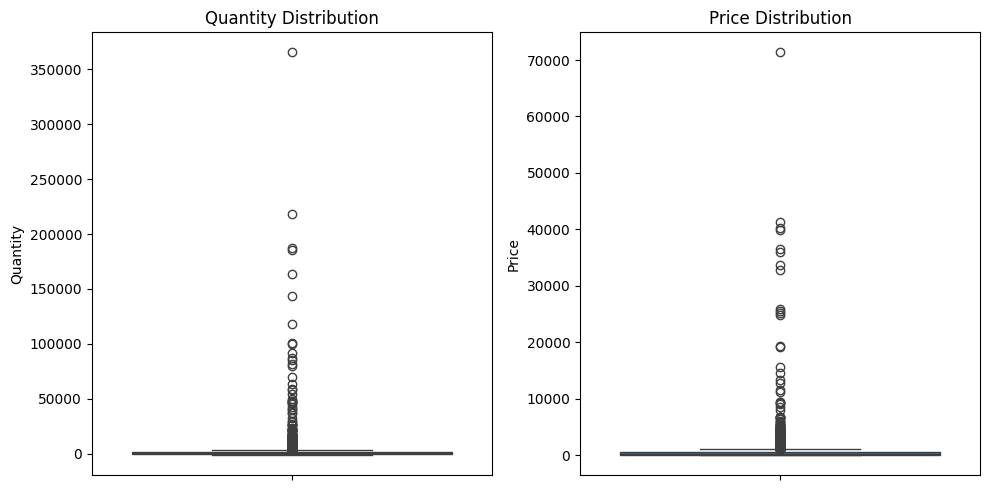

In [8]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=final_df['Quantity'])
plt.title("Quantity Distribution")

plt.subplot(1, 2, 2)
sns.boxplot(y=final_df['Price'])
plt.title("Price Distribution")

plt.tight_layout()
plt.show()

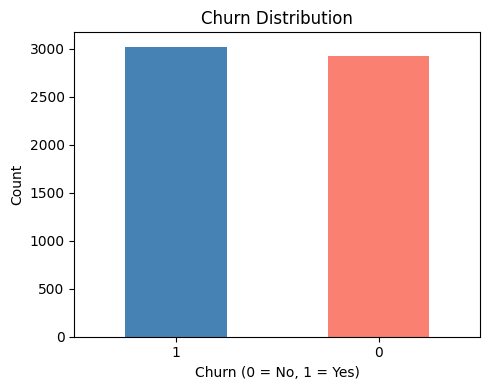

In [9]:
# Churn distribution
plt.figure(figsize=(5, 4))
final_df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Prepare Features and Target

In [10]:
X = final_df.drop(['CustomerID', 'Churn', 'Recency'], axis=1)
y = final_df['Churn']

print("Features:", X.columns.tolist())
print("Target distribution:\n", y.value_counts())

Features: ['Invoice', 'Quantity', 'Price']
Target distribution:
 Churn
1    3020
0    2922
Name: count, dtype: int64


## 9. Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (4456, 3)
Test size: (1486, 3)


## 10. Feature Scaling

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 11. Logistic Regression Model

In [13]:
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression Results")
print(classification_report(y_test, lr_pred))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.75      0.51      0.61       726
           1       0.64      0.83      0.72       760

    accuracy                           0.68      1486
   macro avg       0.69      0.67      0.67      1486
weighted avg       0.69      0.68      0.67      1486



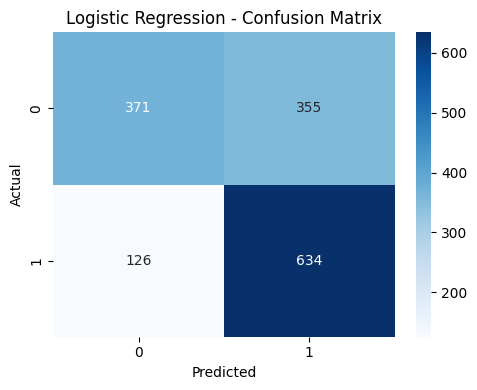

In [14]:
# Confusion Matrix - Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 12. Random Forest Model

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print(classification_report(y_test, rf_pred))

Random Forest Results
              precision    recall  f1-score   support

           0       0.65      0.64      0.65       726
           1       0.66      0.66      0.66       760

    accuracy                           0.65      1486
   macro avg       0.65      0.65      0.65      1486
weighted avg       0.65      0.65      0.65      1486



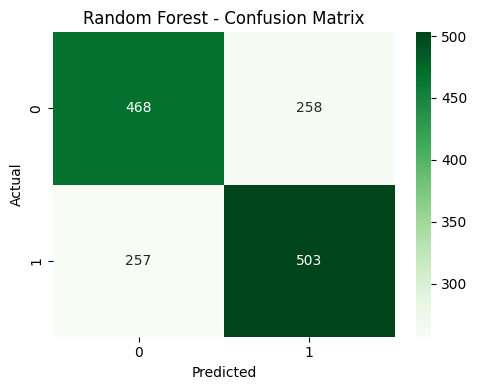

In [16]:
# Confusion Matrix - Random Forest
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

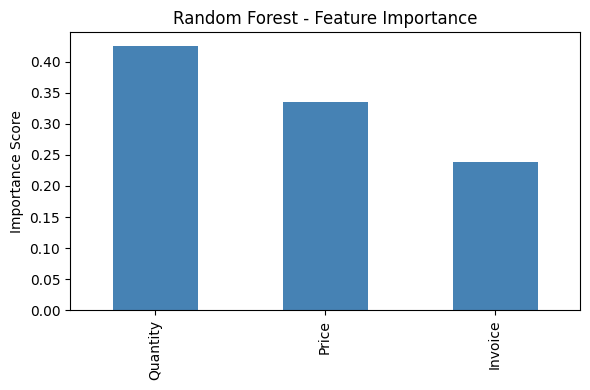

In [17]:
# Feature Importance - Random Forest
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6, 4))
feat_imp.plot(kind='bar', color='steelblue')
plt.title("Random Forest - Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

## 13. XGBoost Model

In [18]:
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Results")
print(classification_report(y_test, xgb_pred))

XGBoost Results
              precision    recall  f1-score   support

           0       0.63      0.62      0.63       726
           1       0.65      0.66      0.65       760

    accuracy                           0.64      1486
   macro avg       0.64      0.64      0.64      1486
weighted avg       0.64      0.64      0.64      1486



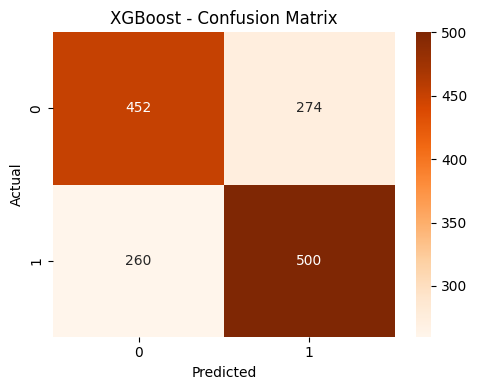

In [19]:
# Confusion Matrix - XGBoost
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 14. Model Comparison

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Probability scores for ROC-AUC
lr_proba  = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_proba  = rf_model.predict_proba(X_test)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

def get_metrics(name, y_true, y_pred, y_proba):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred),  4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred,    zero_division=0), 4),
        'F1 Score':  round(f1_score(y_true, y_pred,        zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba), 4),
    }

results = pd.DataFrame([
    get_metrics('Logistic Regression', y_test, lr_pred,  lr_proba),
    get_metrics('Random Forest',       y_test, rf_pred,  rf_proba),
    get_metrics('XGBoost',             y_test, xgb_pred, xgb_proba),
])

results.set_index('Model', inplace=True)
results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.6763,0.6411,0.8342,0.7250,0.7345
Random Forest,0.6534,0.6610,0.6618,0.6614,0.7302
XGBoost,0.6406,0.6460,0.6579,0.6519,0.7038


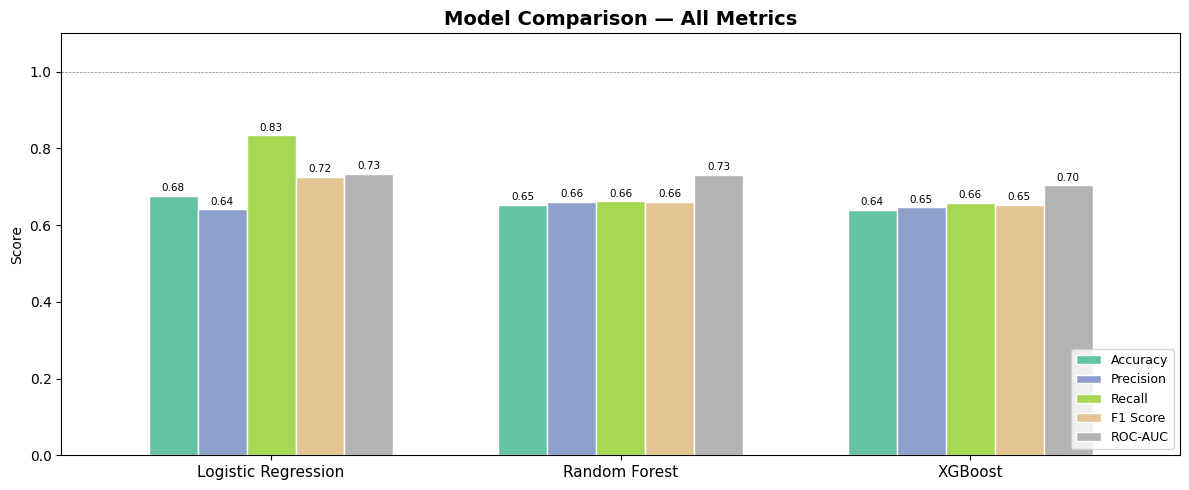

In [21]:
# --- Bar chart: all metrics side by side ---
ax = results.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='white', width=0.7)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_xticklabels(results.index, rotation=0, fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.axhline(1.0, color='grey', linewidth=0.5, linestyle='--')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7.5, padding=2)

plt.tight_layout()
plt.show()

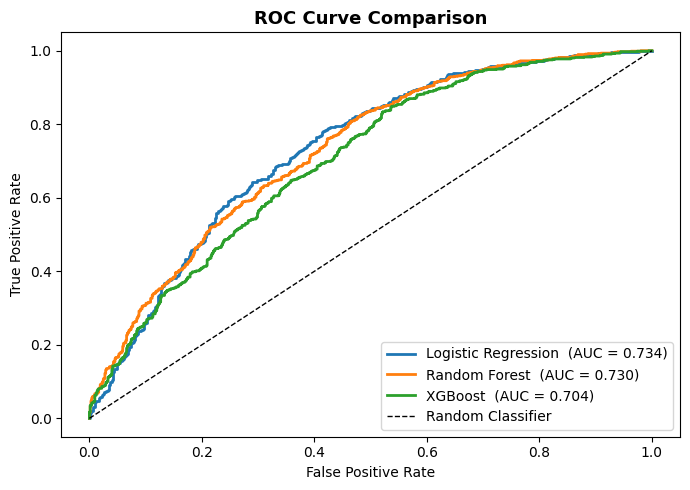

In [22]:
# --- ROC Curves ---
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 5))

for name, y_proba in [
    ('Logistic Regression', lr_proba),
    ('Random Forest',       rf_proba),
    ('XGBoost',             xgb_proba),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

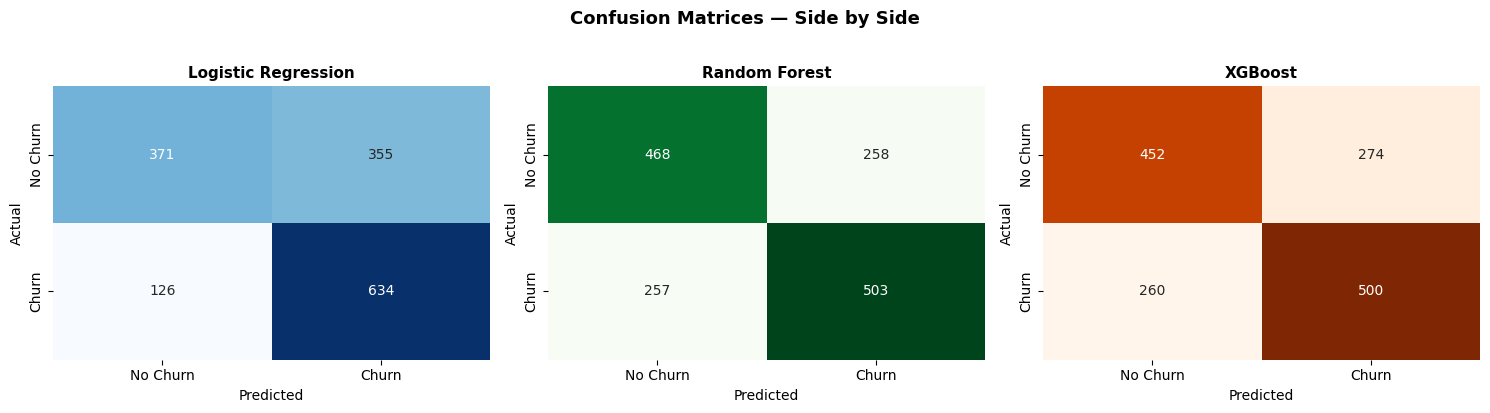

In [23]:
# --- Side-by-side Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    ('Logistic Regression', lr_pred,  'Blues'),
    ('Random Forest',       rf_pred,  'Greens'),
    ('XGBoost',             xgb_pred, 'Oranges'),
]

for ax, (name, preds, cmap) in zip(axes, configs):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                cbar=False)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Side by Side', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# --- Highlight best model ---
best_model = results['F1 Score'].idxmax()
print('=== Summary ===')
print(results.to_string())
print(f'\n✅ Best model by F1 Score: {best_model} ({results.loc[best_model, "F1 Score"]})')

=== Summary ===
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.6763     0.6411  0.8342    0.7250   0.7345
Random Forest          0.6534     0.6610  0.6618    0.6614   0.7302
XGBoost                0.6406     0.6460  0.6579    0.6519   0.7038

✅ Best model by F1 Score: Logistic Regression (0.725)


## Loading with Pickle

In [27]:
## Save model with pickle 

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

In [28]:
## Save the scaler

with open('churn_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)